2025/10/08 11:28:22 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing Decision Tree using PSO...


2025/10/08 11:28:26 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.6869981884463132, Global best: -0.6869981884463132, Runtime: 2.62657 seconds
2025/10/08 11:28:29 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.6869981884463132, Global best: -0.6869981884463132, Runtime: 2.69652 seconds
2025/10/08 11:28:31 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.6869981884463132, Global best: -0.6869981884463132, Runtime: 2.28858 seconds
2025/10/08 11:28:34 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.6869981884463132, Global best: -0.6869981884463132, Runtime: 2.59422 seconds
2025/10/08 11:28:36 PM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.6869981884463132, Global best: -0.6869981884463132, Runtime: 2.28263 seconds
2025/10/08 11:28:36 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(e

PSO Accuracy: 0.6870
PSO Best Params: {'max_depth': 19, 'min_samples_split': 18}

Optimizing Decision Tree using GA...


2025/10/08 11:28:40 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.6801744210607404, Global best: -0.6801744210607404, Runtime: 1.74879 seconds
2025/10/08 11:28:42 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.6801744210607404, Global best: -0.6801744210607404, Runtime: 2.39569 seconds
2025/10/08 11:28:44 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.6838124383413225, Global best: -0.6838124383413225, Runtime: 2.36988 seconds
2025/10/08 11:28:47 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.6838124383413225, Global best: -0.6838124383413225, Runtime: 2.52815 seconds
2025/10/08 11:28:49 PM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.6838124383413225, Global best: -0.6838124383413225, Runtime: 2.51003 seconds
2025/10/08 11:28:49 PM, INFO, mealpy.swarm_based.BA.OriginalBA: Origin

GA Accuracy: 0.6838
GA Best Params: {'max_depth': 17, 'min_samples_split': 13}

Optimizing Decision Tree using Bat...


2025/10/08 11:28:54 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 1, Current best: -0.692456456859427, Global best: -0.692456456859427, Runtime: 2.71677 seconds
2025/10/08 11:28:57 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 2, Current best: -0.692456456859427, Global best: -0.692456456859427, Runtime: 2.96887 seconds
2025/10/08 11:29:00 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 3, Current best: -0.692456456859427, Global best: -0.692456456859427, Runtime: 2.99997 seconds
2025/10/08 11:29:03 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 4, Current best: -0.692456456859427, Global best: -0.692456456859427, Runtime: 3.15580 seconds
2025/10/08 11:29:06 PM, INFO, mealpy.swarm_based.BA.OriginalBA: >>>Problem: P, Epoch: 5, Current best: -0.692456456859427, Global best: -0.692456456859427, Runtime: 3.21849 seconds


Bat Accuracy: 0.6925
Bat Best Params: {'max_depth': 20, 'min_samples_split': 19}



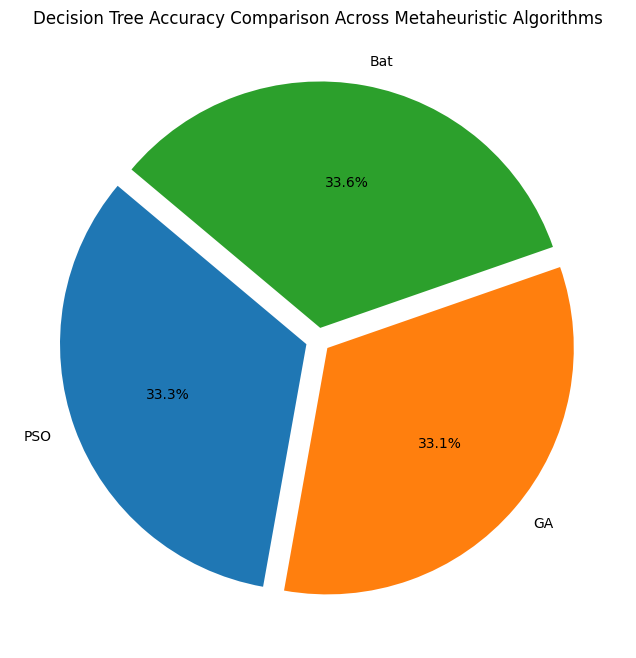

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from mealpy.swarm_based import PSO
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.BA import OriginalBA
import mealpy.swarm_based.BA as bat_algorithm
from mealpy.utils.problem import FloatVar
import warnings

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# Decision Tree Objective Function
# ----------------------------
def dt_objective_function(solution):
    max_depth = int(solution[0])
    min_samples_split = int(solution[1])
    
    try:
        if max_depth < 1:
            max_depth = None
        if min_samples_split < 2:
            min_samples_split = 2
            
        dt = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            random_state=42
        )
        scores = cross_val_score(dt, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)  # Minimize negative accuracy
    except:
        fitness = 1.0
    
    return fitness

# ----------------------------
# Decision Tree Problem Definition
# ----------------------------
dt_problem = {
    "bounds": [
        FloatVar(lb=1, ub=20, name="max_depth"),              # Max depth
        FloatVar(lb=2, ub=20, name="min_samples_split")       # Min samples to split
    ],
    "minmax": "min",
    "obj_func": dt_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": bat_algorithm.OriginalBA(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing Decision Tree using {name}...")
    best_agent = optimizer.solve(dt_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    best_params = {
        'max_depth': int(best_solution[0]),
        'min_samples_split': int(best_solution[1])
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Combined Pie Chart
# ----------------------------
plt.figure(figsize=(8, 8))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("Decision Tree Accuracy Comparison Across Metaheuristic Algorithms")
plt.show()


2025/10/09 12:56:35 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: OriginalPSO(epoch=5, pop_size=10, c1=2.05, c2=2.05, w=0.4)


Optimizing Decision Tree using PSO...


2025/10/09 12:56:47 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 1, Current best: -0.7111118566064555, Global best: -0.7111118566064555, Runtime: 6.81127 seconds
2025/10/09 12:56:54 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 2, Current best: -0.7111118566064555, Global best: -0.7111118566064555, Runtime: 6.60423 seconds
2025/10/09 12:56:59 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 3, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 5.76417 seconds
2025/10/09 12:57:07 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 4, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 7.14541 seconds
2025/10/09 12:57:13 AM, INFO, mealpy.swarm_based.PSO.OriginalPSO: >>>Problem: P, Epoch: 5, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 6.53489 seconds
2025/10/09 12:57:13 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: BaseGA(e

PSO Accuracy: 0.7116
PSO Best Params: {'max_depth': 27, 'min_samples_split': 4, 'min_samples_leaf': 3, 'criterion': 'gini'}

Optimizing Decision Tree using GA...


2025/10/09 12:57:21 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 1, Current best: -0.7088349895754901, Global best: -0.7088349895754901, Runtime: 4.08561 seconds
2025/10/09 12:57:27 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 2, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 5.86731 seconds
2025/10/09 12:57:34 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 3, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 6.94552 seconds
2025/10/09 12:57:41 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 4, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 7.02161 seconds
2025/10/09 12:57:47 AM, INFO, mealpy.evolutionary_based.GA.BaseGA: >>>Problem: P, Epoch: 5, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 6.34361 seconds
2025/10/09 12:57:47 AM, INFO, mealpy.swarm_based.BA.OriginalBA: Origin

...

Cuckoo Accuracy: 0.7175
Cuckoo Best Params: {'max_depth': 30, 'min_samples_split': 3, 'min_samples_leaf': 3, 'criterion': 'gini'}

Optimizing Decision Tree using Firefly...


2025/10/09 01:03:50 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 1, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 62.09922 seconds
2025/10/09 01:05:19 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 2, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 89.07165 seconds
2025/10/09 01:06:13 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 3, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 53.77656 seconds
2025/10/09 01:07:06 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 4, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 53.39542 seconds
2025/10/09 01:08:01 AM, INFO, mealpy.swarm_based.FA.OriginalFA: >>>Problem: P, Epoch: 5, Current best: -0.7115666087665282, Global best: -0.7115666087665282, Runtime: 54.85447 seconds
2025/10/09 01:08:01 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: OriginalABC(ep

Firefly Accuracy: 0.7116
Firefly Best Params: {'max_depth': 27, 'min_samples_split': 2, 'min_samples_leaf': 3, 'criterion': 'gini'}

Optimizing Decision Tree using ABC...


2025/10/09 01:08:10 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 1, Current best: -0.7129283802622653, Global best: -0.7129283802622653, Runtime: 6.48499 seconds
2025/10/09 01:08:17 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 2, Current best: -0.7129283802622653, Global best: -0.7129283802622653, Runtime: 7.02710 seconds
2025/10/09 01:08:24 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 3, Current best: -0.7147486313947969, Global best: -0.7147486313947969, Runtime: 7.13328 seconds
2025/10/09 01:08:32 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 4, Current best: -0.7165688825273286, Global best: -0.7165688825273286, Runtime: 7.51192 seconds
2025/10/09 01:08:39 AM, INFO, mealpy.swarm_based.ABC.OriginalABC: >>>Problem: P, Epoch: 5, Current best: -0.7165688825273286, Global best: -0.7165688825273286, Runtime: 7.38343 seconds


ABC Accuracy: 0.7166
ABC Best Params: {'max_depth': 30, 'min_samples_split': 8, 'min_samples_leaf': 3, 'criterion': 'gini'}



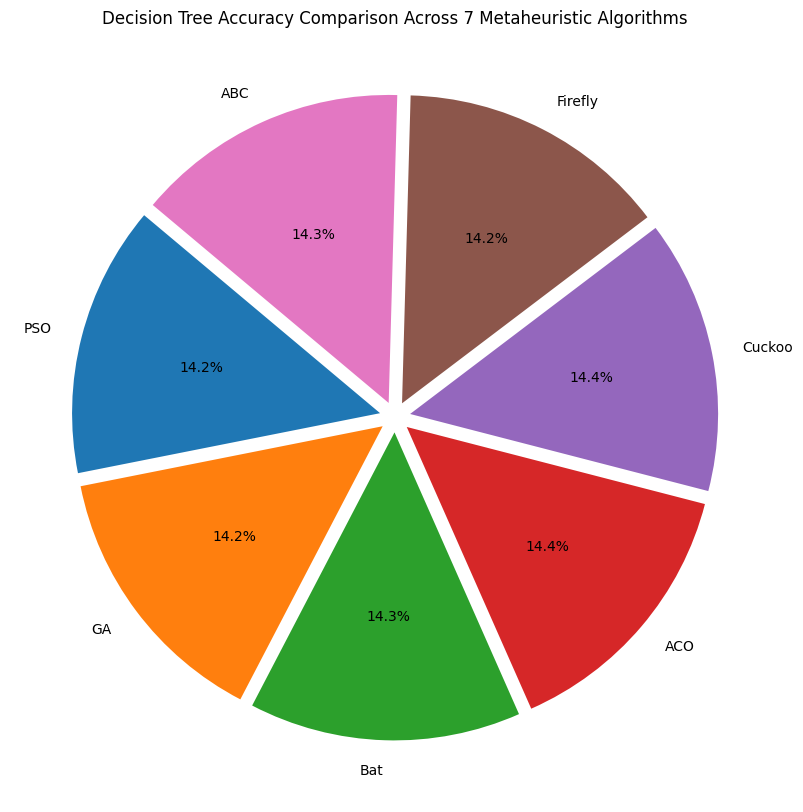

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import warnings

# ----------------------------
# Mealpy algorithm imports (latest structure)
# ----------------------------
from mealpy.swarm_based import PSO, BA, CSO, FA, ABC
from mealpy.evolutionary_based import GA
from mealpy.swarm_based.ACOR import OriginalACOR
from mealpy.utils.problem import FloatVar

warnings.filterwarnings('ignore')

# ----------------------------
# Load dataset
# ----------------------------
def load_data():
    amazon = pd.read_csv("amazon_cells_labelled.txt", sep="\t", header=None, names=["text", "label"])
    imdb   = pd.read_csv("imdb_labelled.txt", sep="\t", header=None, names=["text", "label"])
    yelp   = pd.read_csv("yelp_labelled.txt", sep="\t", header=None, names=["text", "label"])
    
    df = pd.concat([amazon, imdb, yelp], axis=0)
    from sklearn.feature_extraction.text import TfidfVectorizer
    vectorizer = TfidfVectorizer(stop_words="english", max_features=1000)
    X = vectorizer.fit_transform(df["text"]).toarray()
    y = df["label"].values
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = load_data()

# ----------------------------
# Decision Tree Objective Function
# ----------------------------
def dt_objective_function(solution):
    max_depth = int(solution[0])
    min_samples_split = int(solution[1])
    min_samples_leaf = int(solution[2])
    criterion_idx = int(solution[3])
    criterion = 'gini' if criterion_idx == 0 else 'entropy'
    
    try:
        dt = DecisionTreeClassifier(
            criterion=criterion,
            max_depth=max_depth if max_depth > 0 else None,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            random_state=42
        )
        scores = cross_val_score(dt, X_train, y_train, cv=3, scoring='accuracy')
        fitness = -np.mean(scores)
    except:
        fitness = 1.0
    return fitness

# ----------------------------
# Decision Tree Problem Definition
# ----------------------------
dt_problem = {
    "bounds": [
        FloatVar(lb=2, ub=30, name="max_depth"),
        FloatVar(lb=2, ub=10, name="min_samples_split"),
        FloatVar(lb=1, ub=5, name="min_samples_leaf"),
        FloatVar(lb=0, ub=1, name="criterion")   # 0=gini, 1=entropy
    ],
    "minmax": "min",
    "obj_func": dt_objective_function
}

# ----------------------------
# Run All Algorithms
# ----------------------------
algorithms = {
    "PSO": PSO.OriginalPSO(epoch=5, pop_size=10),
    "GA": GA.BaseGA(epoch=5, pop_size=10),
    "Bat": BA.OriginalBA(epoch=5, pop_size=10),
    "ACO": OriginalACOR(epoch=5, pop_size=10),
    "Cuckoo": CSO.OriginalCSO(epoch=5, pop_size=10),
    "Firefly": FA.OriginalFA(epoch=5, pop_size=10),
    "ABC": ABC.OriginalABC(epoch=5, pop_size=10)
}

results = {}

for name, optimizer in algorithms.items():
    print(f"Optimizing Decision Tree using {name}...")
    best_agent = optimizer.solve(dt_problem)
    best_solution = best_agent.solution
    best_fitness = -best_agent.target.fitness
    
    criterion = 'gini' if int(best_solution[3]) == 0 else 'entropy'
    best_params = {
        'max_depth': int(best_solution[0]),
        'min_samples_split': int(best_solution[1]),
        'min_samples_leaf': int(best_solution[2]),
        'criterion': criterion
    }
    
    results[name] = best_fitness
    print(f"{name} Accuracy: {best_fitness:.4f}")
    print(f"{name} Best Params: {best_params}\n")

# ----------------------------
# Pie Chart
# ----------------------------
plt.figure(figsize=(10, 10))
plt.pie(results.values(), labels=results.keys(), autopct='%1.1f%%', startangle=140, explode=[0.05]*len(results))
plt.title("Decision Tree Accuracy Comparison Across 7 Metaheuristic Algorithms")
plt.show()


In [1]:
from mealpy.swarm_based import CSO
print(dir(CSO))


['Agent', 'Optimizer', 'OriginalCSO', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'np']
